In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set,elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [2]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [
                        6894, # GM pet
                        6895, # GM pet
                        3080, # GM pet
                        9031, # GM pet
                        6980, # Vulbis
                        31886, # Venerable petmount
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        22206, # Alianza de corrupcion
                        22205, # Anillo de corrupcion
                        7754, # Dofus ocre
                              ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        # 29: {
                        #     "target": 70,  # Crit
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }, 
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        }, 
                        28 : {
                            "target": 6, # Summons
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {} 
                },
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    28:1, # Exo Summons
                    # 8:1
                    },  # Exo MP
                "distributed_points": {
                    # 45: 995,  # Strength
                },
                "elements" : [
                    # 36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
            },
        }

In [3]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
Items[Items["name"].str.contains("ocre", case=False)]

,name,set,level
26738,Tarja del dragón ocre,Set cosmético del dragón ocre,1
20129,Réplica del dofus Ocre,None,1
21705,Dofus Ocre recién pintado,None,1
26737,Capa del dragón ocre,Set cosmético del dragón ocre,1
7754,Dofus Ocre,None,160
26801,Dragón ocre,None,1
26366,Anillo ocre,None,40
26734,Casco de dragón ocre,Set cosmético del dragón ocre,1


In [5]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2743
Total item sets: 147
Total pools:
   16 with sizes [68, 116, 1, 1, 62, 81, 39, 88, 69, 411, 1, 326, 326, 326, 326, 326]
Total combinations: 10^28.15


In [ ]:
solutions = opt.optimize(islands = 10, max_workers = 4)

In [ ]:
for idx, solution in enumerate(sorted(solutions, key=lambda x: x.fitness, reverse=True)):
    if solution.penalized:
        continue
    print(f"Solution {idx}:")
    print("\tFitness:", solution.get_fitness())
    print("\tWeapon damage:", solution.get_final_weapon_damage())
    print("\tElemental damage:", solution.get_final_elemental_damage())
    # print("\tIs the solution viable?", solution.viable)
    # print("\tWas the solution penalized?", solution.penalized)

    print("\tPreferences:")
    df = solution.totals_summary(effect_descriptions)
    for bound, preference in solution.preferences.items():
        for element, details in preference.items():
            row = df.loc[element]
            print(f"\t\t{row['description']} : {row['value']}")
    print("\tCharacteristics:")
    for element in elements:
        print(f"\t\t{df.loc[element]['description']}: {df.loc[element]['value']}")

    print("\tItems:")
    print("\t\tType\tDescription\tLevel")
    for item,row in solution.set_summary().sort_values("type").iterrows():
        # Prettify the output
        print(f"\t\t{row['type']}\t{row['description']}\t{row['level']}")
    print("\tChromosome:")
    print("\t\t", solution.chromosome)

Solution 0:
	Fitness: 1211.6
	Weapon damage: 1211.6
	Elemental damage: 435.2
	Preferences:
		PA : 12.0
		PM : 6.0
		vitalidad : 4000.0
		invocaciones : 6.0
		% resistencia neutral : 34.0
		% resistencia al fuego : 20.0
		% resistencia al aire : 17.0
		% resistencia al agua : 20.0
		% resistencia a la tierra : 49.0
	Characteristics:
		agilidad: 270.0
		suerte: 270.0
		inteligencia: 420.0
		fuerza: 1256.0
		vitalidad: 4000.0
		sabiduría: 450.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de vueloceronte	200
		Anillo	Anillo de Corrupción	200
		Anillo	Alianza de Corrupción	200
		Bota	Botarpilla	200
		Capa	Capilla	200
		Cinturón	Cinturón de vueloceronte	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus de los hielos	180
		Dofus	Dofus Ocre	160
		Dofus	Dolmanax	100
		Escudo	Paravela de Mami Ayuto	200
		Espada	Espada Lingüe	196
		Mascota	Feanor	20
		Sombrero	Pañoleta de Mami Ayuto	200
		Trofeo	Hércules mayor	150
		Trofeo	Robusto mayor	150
	Chromosome:
		 [19984 11744 22205 22206 19983 15748 30

In [ ]:
solution.totals_summary(effect_descriptions).sort_values("description",ascending=False)

,description,value
9,vitalidad,4000.0
22,suerte,210.0
10,sabiduría,440.0
25,prospección,40.0
32,potencia (daños generales),350.0
26,placaje,-7.0
28,invocaciones,6.0
13,inteligencia,320.0
24,iniciativa,300.0
59,huida,22.0


In [ ]:
set_summary = solution.set_summary()
set_summary

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
7043,13,Dofus,Dofus de los hielos,180,None
11744,2,Espada,Espada Lingüe,196,None
13344,13,Dofus,Dolmanax,100,None
13659,5,Bota,Zuecos Traz,196,None
13828,13,Trofeo,Robusto mayor,150,None
14091,1,Amuleto,Amuleto de kukoloide,200,Set de kukoloide
14848,12,Mascotura,Kompost,60,None
14937,11,Capa,Capa de los justicieros,200,Set de los justicieros
15695,10,Sombrero,Maskrobio,200,Set de los krobios


Text(0, 0.5, 'Best Fitness')

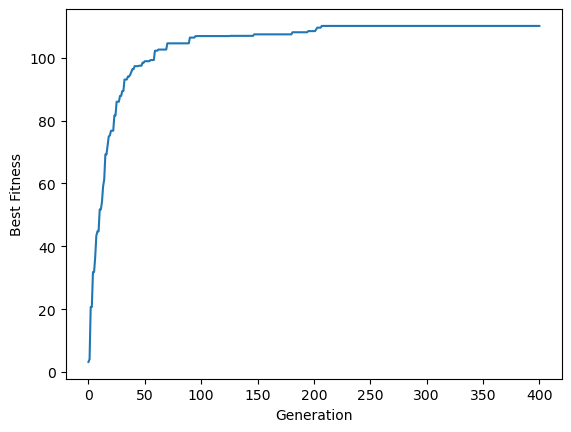

In [ ]:
import matplotlib.pyplot as plt
plt.plot(solution.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [ ]:
assert False

AssertionError: 

In [ ]:
Items[Items["name"].str.contains("anillo de corrupc",case=False)]

,name,set,level
22205,Anillo de Corrupción,Set de Corrupción,200


In [ ]:
# Test
chr = Chromosome(
                  [
                      19984, 
                      # 11744,
                      14055,
                      22205, 22206, 19983, 15748, 30858, 30860, 15747, 8693, 7043, 7754,
                      13344, 13828, 13759, 694
                  ],
                 opt)
chr.fitness

1176.12

In [ ]:
Items[Items["name"].str.contains("ling",case=False)]

,name,set,level
15654,Frasco vacío del doctor Dil Linguer,None,180
15463,Lingote de Anutropía,None,100
15653,Frasco vacío del doctor Dil Linguer,None,180
13220,Fular de Explingon,None,1
19691,Pergamino traducido por Aisling,None,1
11744,Espada Lingüe,None,196
15655,Frasco vacío del doctor Dil Linguer,None,180
15652,Frasco vacío del doctor Dil Linguer,None,180
15569,Frasco vacío del doctor Dil Linguer,None,180
745,Lingote de oro,None,10


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)